# Ensemble ML — Student Development Notebook
Use this notebook to develop and test your model before submitting.

> **Important:** Always use *Kernel → Restart Kernel and Run All Cells* after making changes to `studentN.py`. This ensures Python is not using a stale cached version of your code.

**Steps:**
1. Set `STUDENT_NUMBER` in the next cell to your student number
2. Run sections 1–5 to verify your `studentN.py` is working correctly
3. Use the scratch cells in section 6 to explore the data and prototype your algorithm
4. Once happy, copy your logic into `studentN.py` and use *Kernel → Restart Kernel and Run All Cells* to confirm

In [11]:
# ── CHANGE THIS TO YOUR STUDENT NUMBER (1-5) ─────────────────────────────────
STUDENT_NUMBER = 4
# ─────────────────────────────────────────────────────────────────────────────

TICKER     = 'DELL'
START_DATE = '2018-12-28'
END_DATE   = '2025-12-31'

## 1. Load your model

In [12]:
import importlib
import sys

# force reload model.py and studentN.py so kernel cache never causes stale attribute errors
for mod in ['model', f'student{STUDENT_NUMBER}']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

module_name = f'student{STUDENT_NUMBER}'
class_name  = f'Student{STUDENT_NUMBER}Model'

module     = importlib.import_module(module_name)
ModelClass = getattr(module, class_name)

model = ModelClass(TICKER, START_DATE, END_DATE)
print(f'Loaded: {model.name}')

Loaded: Student 4 Model -- Random Forest


## 2. Inspect the data splits

In [13]:
print(f'Total rows : {len(model.data)}')
print(f'Train      : {model.train_set.index[0].date()} -> {model.train_set.index[-1].date()}  ({len(model.train_set)} days)')
print(f'[purge 1 month]')
print(f'Refine     : {model.refine_set.index[0].date()} -> {model.refine_set.index[-1].date()}  ({len(model.refine_set)} days)')
print(f'[purge 1 month]')
print(f'Evaluate   : {model.evaluate_set.index[0].date()} -> {model.evaluate_set.index[-1].date()}  ({len(model.evaluate_set)} days)')

Total rows : 1761
Train      : 2018-12-28 -> 2024-08-02  (1408 days)
[purge 1 month]
Refine     : 2024-09-03 -> 2025-04-16  (156 days)
[purge 1 month]
Evaluate   : 2025-05-19 -> 2025-12-30  (156 days)


In [14]:
# preview training data
model.train_set.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-07-29,108.018478,112.195455,107.775631,111.088072,7552200
2024-07-30,105.502579,110.009824,102.743830,109.096716,11938400
2024-07-31,110.427536,113.263991,108.989877,111.476638,11327300
2024-08-01,105.327736,111.913754,104.453484,109.698987,8570000
2024-08-02,99.363396,100.830195,97.070917,98.790272,11832700


## 3. Plot the splits

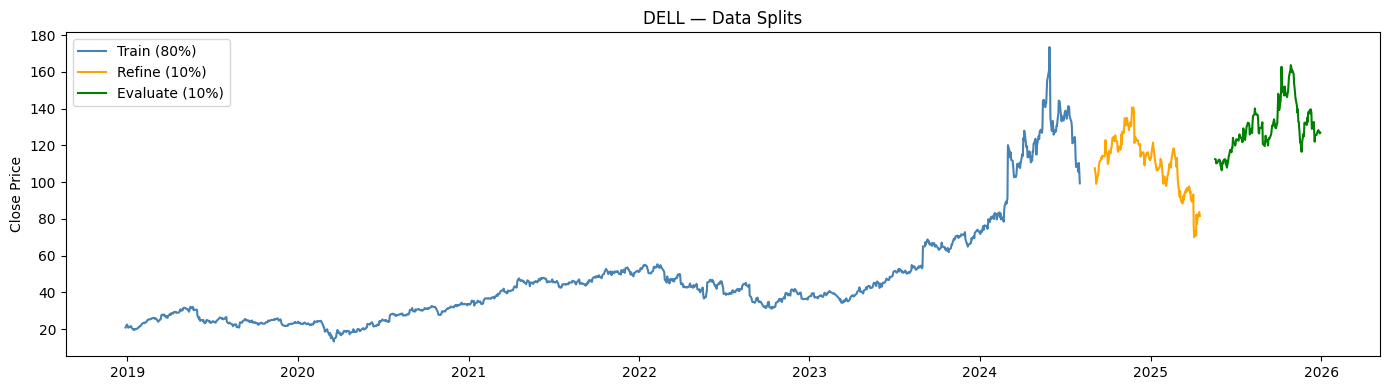

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(model.train_set.index,    model.train_set['Close'],    label='Train (80%)',    color='steelblue')
ax.plot(model.refine_set.index,   model.refine_set['Close'],   label='Refine (10%)',   color='orange')
ax.plot(model.evaluate_set.index, model.evaluate_set['Close'], label='Evaluate (10%)', color='green')
ax.set_title(f'{TICKER} — Data Splits')
ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Run the three stages

In [16]:
print('Stage 1 — train()')
try:
    model.train()
    print('  done')
except NotImplementedError:
    print('  NOT YET IMPLEMENTED — add your logic to train() in student{}.py'.format(STUDENT_NUMBER))


Stage 1 — train()
[Student4] Train accuracy: 0.725
  done


In [17]:
print('Stage 2 — refine_model()')
try:
    model.refine_model()
    print('  done')
except NotImplementedError:
    print('  NOT YET IMPLEMENTED — add your logic to refine_model() in student{}.py'.format(STUDENT_NUMBER))


Stage 2 — refine_model()
[Student4] Refine  max_depth=   3  acc=0.506
[Student4] Refine  max_depth=   4  acc=0.481
[Student4] Refine  max_depth=   5  acc=0.500
[Student4] Refine  max_depth=   6  acc=0.500
[Student4] Refine  max_depth=   8  acc=0.500
[Student4] Refine  max_depth=  10  acc=0.526
[Student4] Refine  max_depth=None  acc=0.513
[Student4] Best depth after refinement: 10  (refine acc=0.526)
  done


In [18]:
print('Stage 3 — predict()')
signal = None
try:
    signal = model.predict()
    print(f'  signal: {signal}  ({"UP" if signal == 1 else "DOWN" if signal == -1 else "INVALID"})')
except NotImplementedError:
    print('  NOT YET IMPLEMENTED — add your logic to predict() in student{}.py'.format(STUDENT_NUMBER))


Stage 3 — predict()
[Student4] Evaluate accuracy: 0.545  |  Signal: +1
  signal: 1  (UP)


## 5. Validate signal

In [19]:
if signal is None:
    print('Skipping validation — predict() not yet implemented')
else:
    assert signal in (1, -1), f'predict() must return 1 or -1, got {signal}'
    print(f'Validation passed — {model.name} returns a valid signal: {signal}')


Validation passed — Student 4 Model -- Random Forest returns a valid signal: 1


## 6. Scratch space — develop your model here
Use the cells below freely to explore the data and prototype your algorithm.
Once happy, copy your logic into `studentN.py` and re-run cells 2–5 above to confirm.

In [20]:
# explore model.train_set, model.refine_set, model.evaluate_set here
model.train_set.describe()

Price,Close,High,Low,Open,Volume
count,1408.000000,1408.000000,1408.000000,1408.000000,1.408000e+03
mean,45.624247,46.317420,44.921310,45.613177,5.265248e+06
std,27.018823,27.674186,26.385432,27.071238,4.678068e+06
min,13.314331,13.904645,11.764759,13.374285,1.140591e+06
25%,27.622514,27.987999,27.356177,27.610982,3.014645e+06
50%,39.604748,40.218573,39.163598,39.634302,4.076898e+06
75%,50.343096,50.827258,49.576582,50.119283,5.924393e+06
max,173.480927,173.955252,159.831671,173.084024,6.719280e+07


In [21]:
# scratch cell


In [22]:
# scratch cell
